In [1]:
from aqua.diagnostics import Climatology, PlotBias
from matplotlib import pyplot as plt

gb = Climatology(
    catalog="ci",
    model="ERA5",
    exp="era5-hpz3",
    source="monthly",
    regrid="r100",
    outputdir=".",
)
climatology_instance = gb.retrieve()
plotgb = PlotBias(dpi="10", outputdir=".")
var = "q"
outdir = gb.outputdir

# Seasonal climatology required (due to parallelisation,
# earlier tests may not have run on this worker)
gb.compute_climatology(var=var, seasonal=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshel

In [2]:
gb.seasonal_climatology

<xarray.Dataset> Size: 17MB
Dimensions:  (season: 4, lat: 180, lon: 360, plev: 8)
Coordinates:
  * season   (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * plev     (plev) float64 64B 1e+03 5e+03 1e+04 ... 7e+04 8.5e+04 1e+05
Data variables:
    q        (season, plev, lat, lon) float64 17MB 3.256e-06 ... 0.0009619
Attributes: (12/15)
    AQUA_catalog:        ci
    AQUA_model:          ERA5
    AQUA_exp:            era5-hpz3
    AQUA_realization:    r1
    AQUA_startdate:      1990-01-01
    AQUA_enddate:        1994-12-01
    ...                  ...
    model:               ERA5
    exp:                 era5-hpz3
    realization:         r1
    var:                 q
    timestamp:           2026-09-16 11:06:34
    aqua_version:        1.1.0

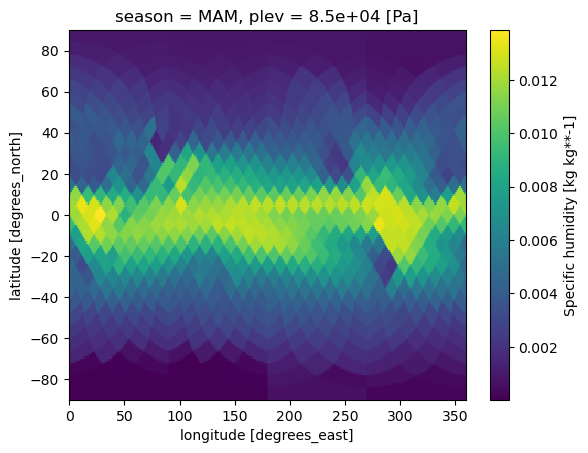

In [ ]:
%matplotlib inline
gb.seasonal_climatology["q"].sel(plev=85000).sel(season="MAM").plot()

In [9]:
plotgb.plot_seasonal_bias(data=gb.seasonal_climatology, data_ref=gb.seasonal_climatology, var=var, plev=85000)

2026-09-16 11:09:11 :: plot_single_map :: ERROR    -> The map is zero! You are trying to plot an empty dataset


TypeError: 'GeometryCollection' object is not subscriptable

Error in callback <function _draw_all_if_interactive at 0x10ff7d850> (for post_execute), with arguments args (),kwargs {}:


TypeError: 'GeometryCollection' object is not subscriptable

TypeError: 'GeometryCollection' object is not subscriptable

<Figure size 1000x800 with 1 Axes>

In [30]:
da = gb.seasonal_climatology["q"].sel(plev=85000).sel(season="DJF")
print(da.shape, da.min().values, da.max().values)
print(int(da.isnull().sum()), "NaNs out of", da.size)

(180, 360) 0.00021952169287639355 0.013790513761341572
0 NaNs out of 64800


In [32]:
import numpy as np

lon = da.lon.values
lat = da.lat.values

print(lon.min(), lon.max(), lon[:5], lon[-5:])
print(lat.min(), lat.max(), lat[:5], lat[-5:])

# monotonic?
print(np.all(np.diff(lon) > 0), np.all(np.diff(lat) > 0))

# duplicates (common cause of zero-width/zero-height cells)
print(len(lon) - len(np.unique(lon)), len(lat) - len(np.unique(lat)))

0.0 359.0 [0. 1. 2. 3. 4.] [355. 356. 357. 358. 359.]
-89.5 89.5 [-89.5 -88.5 -87.5 -86.5 -85.5] [85.5 86.5 87.5 88.5 89.5]
True True
0 0


/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/homebrew/Caskroom/mambaforge/base/envs/aqua-dev/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


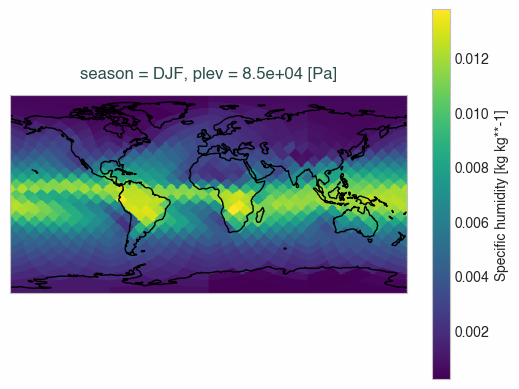

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt


fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
cs = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=True)
ax.set_global()  # <- force full extent regardless of bad autoscale
ax.coastlines()
plt.show()

In [24]:
plotgb.plot_seasonal_bias(data=gb.seasonal_climatology, data_ref=gb.seasonal_climatology * 0.99, var=var, plev=85000)
# pdf = os.path.join(outdir, "pdf", f"biases.seasonal_bias.ci.ERA5.era5-hpz3.r1.ERA5.era5-hpz3.{var}.85000.pdf")
# assert os.path.exists(pdf)
# png = os.path.join(outdir, "png", f"biases.seasonal_bias.ci.ERA5.era5-hpz3.r1.ERA5.era5-hpz3.{var}.85000.png")
# assert os.path.exists(png)

TypeError: 'GeometryCollection' object is not subscriptable

In [2]:
import xarray as xr
import s3fs

# Anonymous access (works if the bucket allows public/anonymous reads)
fs = s3fs.S3FileSystem(anon=True)

store = fs.get_mapper(
    "s3://aqua-lra-zarr-files/climatedt-gen2-zarr/IFS-NEMO-5km/baseline-hist/ifs-nemo-5km_baseline-hist.zarr/"
)

ds = xr.open_zarr(store)

GroupNotFoundError: No group found in store <fsspec.mapping.FSMap object at 0x30013df90> at path ''